# Supermarket Sales Analysis
## Notebook 02 - Análise Exploratória (EDA)

**Objetivo:** Explorar os dados limpos para identificar padrões, tendências e insights estratégicos.

In [9]:
import pandas as pd

df = pd.read_csv('../data/supermarket_clean.csv' , parse_dates=['Date'])

print('Shape:' , df.shape)
df.head()

Shape: (1000, 20)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross income,Rating,hour,month,month_name,day_of_week
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,26.1415,9.1,13,1,Jan,Saturday
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,3.8200,9.6,10,3,Mar,Friday
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,16.2155,7.4,13,3,Mar,Sunday
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,23.2880,8.4,20,1,Jan,Sunday
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,30.2085,5.3,10,2,Feb,Friday


In [10]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,Date,cogs,gross income,Rating,hour,month
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,15.379369,6.97270,14.910000,1.993000
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,0.508500,4.00000,10.000000,1.000000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,5.924875,5.50000,12.000000,1.000000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,12.088000,7.00000,15.000000,2.000000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,22.445250,8.50000,18.000000,3.000000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,49.650000,10.00000,20.000000,3.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,11.708825,1.71858,3.186857,0.835254


## Receita por Filial

In [11]:
receita_filial = df.groupby('Branch')['Sales'].sum().sort_values(ascending=False)
print(receita_filial)

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


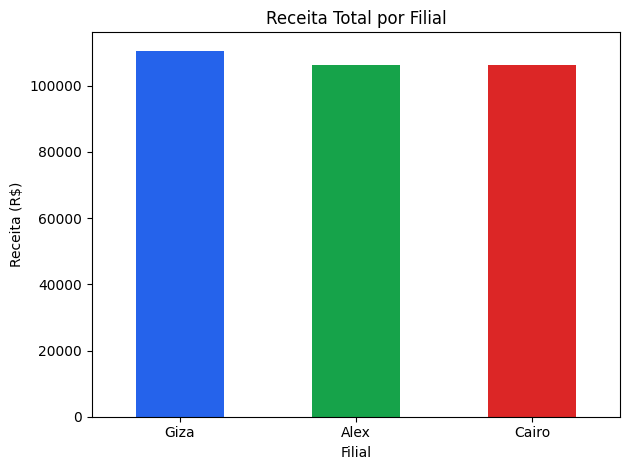

In [12]:
import matplotlib.pyplot as plt

receita_filial.plot(kind='bar', color=['#2563EB', '#16A34A', '#DC2626'])

plt.title('Receita Total por Filial')
plt.xlabel('Filial')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Produtos mais lucrativos

In [13]:
receita_produto = df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)
print(receita_produto)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


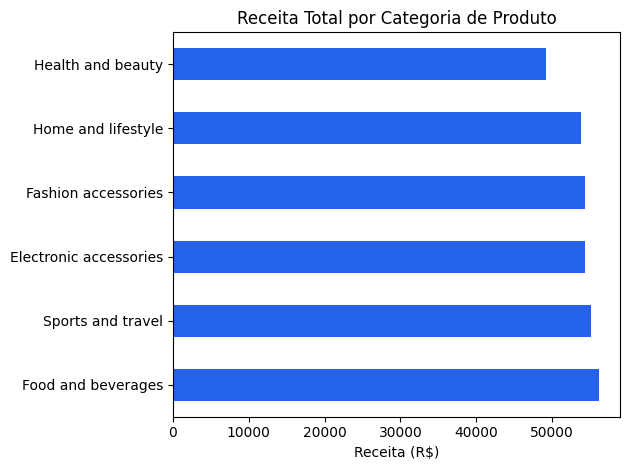

In [14]:
receita_produto.plot(kind='barh', color='#2563EB')

plt.title('Receita Total por Categoria de Produto')
plt.xlabel('Receita (R$)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Horário do pico de vendas

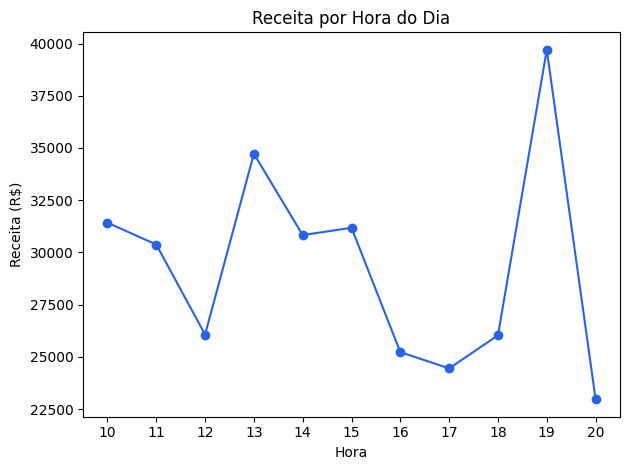

In [15]:
vendas_hora = df.groupby('hour')['Sales'].sum()

vendas_hora.plot(kind='line', marker='o', color='#2563EB')

plt.title('Receita por Hora do Dia')
plt.xlabel('Hora')
plt.ylabel('Receita (R$)')
plt.xticks(vendas_hora.index)
plt.tight_layout()
plt.show()

## Avaliação média por categoria

In [16]:
rating_produto = df.groupby('Product line')['Rating'].mean().sort_values(ascending=False)
print(rating_produto.round(2))

Product line
Food and beverages        7.11
Fashion accessories       7.03
Health and beauty         7.00
Electronic accessories    6.92
Sports and travel         6.92
Home and lifestyle        6.84
Name: Rating, dtype: float64
